# Sprawozdanie z projektu
### Jakub Załuga WIG23AX1S0

W ramach projetku przygotowano algorytmu uczena maszynowego i proste sieci neuronowe przewidujące czas przejazdu rowerem miejskim w Bostonie na bazie dnaych o wypożyczeniach rowerów i dziennych danych pogodowych. Dane pochodzą z platformy Kaggle. Bazują na bazach danych:
"Bike Sharing in Boston", "Boston Weather 2013-2023"
Dane przygotowano, sprawdzono i usunięto wartości odstające. Dla danych o wypożyczeniach dodano dodatkowe kolumny ułatwiające algorytmom zrozumienie problemu i poprawiające wyniki. Dane zostały zwizualizowane za pomocą wykresów. Wybrano trzy algorytmu uczenia maszynowego z których wybrano jeden i sprawdzono jego działanie. Do uczenia maszynowego i sieci neuronowych wykorzystano bibiotekę Sklearn. Dla sztucznych sieci neuronowych zastosowano pipeline, gdzie sprawdzono sieci jedno i dwuwarstwowe dla dwóch metod aktywacji.
Wynikowe algorytmy wyuczono na wszystkich dostępnych rekordach. Na początkowym etapie wybrano losowo 50 000 rekordów aby wybrać początkowe parametry i przygotować pipeline wybierając najlepsze parametry oraz sprawdzenie które cechu najsilniej wpłynęły na algorytm.
Obliczenia wykonano na laptopie z procesorem i7 12 generacji z 12 wątkami. 

### Import bibiotek
Poza bibliotekami umożliwiającymi przygotowanie danych, wytrenowania sieci i algorytmów wykorzystano bibliotekę scikit-learn-intelex, umożlwiającą wykorzystanie pełnego potencjału procesora do obliczeń.

In [ ]:
import numpy as np
import pandas as pd 
import geopandas as gpd

from sklearnex import patch_sklearn
patch_sklearn()


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor


import time
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib



Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


### Wczytanie danych pogodowych

In [2]:
df_weather = pd.read_csv('data/boston_weather_data.csv')

df_weather.shape
df_weather.info()
df_weather.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    3653 non-null   object 
 1   tavg    3652 non-null   float64
 2   tmin    3653 non-null   float64
 3   tmax    3653 non-null   float64
 4   prcp    3653 non-null   float64
 5   wdir    3066 non-null   float64
 6   wspd    3653 non-null   float64
 7   pres    3492 non-null   float64
dtypes: float64(7), object(1)
memory usage: 228.4+ KB


,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,3652.000000,3653.000000,3653.000000,3653.000000,3066.000000,3653.000000,3492.000000
mean,11.549863,7.507692,15.875691,2.936819,200.876712,17.555407,1016.520790
std,9.559483,9.386869,10.221851,7.505755,100.070063,6.009118,7.767252
min,-17.800000,-23.300000,-12.100000,0.000000,0.000000,2.500000,983.900000
25%,3.900000,0.600000,7.200000,0.000000,112.000000,13.300000,1011.400000
50%,11.500000,7.800000,15.600000,0.000000,226.500000,16.600000,1016.400000
75%,19.900000,15.600000,24.400000,1.500000,279.000000,20.900000,1021.600000
max,32.300000,28.300000,37.800000,78.000000,360.000000,61.200000,1042.400000


Sprawdzenie ile jest wartości brakujących
Jako, że wyszstkie kolumny mają datatype inny niż object(poza kolumną time) sprawdzono tylko wartość Nan

In [3]:
for column in df_weather.columns:
    missing_count = df_weather[column].isnull().sum()
    print(f'Column: {column}, Missing values: {missing_count}')

Column: time, Missing values: 0
Column: tavg, Missing values: 1
Column: tmin, Missing values: 0
Column: tmax, Missing values: 0
Column: prcp, Missing values: 0
Column: wdir, Missing values: 587
Column: wspd, Missing values: 0
Column: pres, Missing values: 161


Sprawdzenie wartośći tavg

In [4]:
df_temp = df_weather.copy()
df_temp['tavg'] = df_temp.apply(lambda row: (row['tmin'] + row['tmax']) / 2, axis=1)
df_temp.describe()

,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,3653.000000,3653.000000,3653.000000,3653.000000,3066.000000,3653.000000,3492.000000
mean,11.691692,7.507692,15.875691,2.936819,200.876712,17.555407,1016.520790
std,9.671689,9.386869,10.221851,7.505755,100.070063,6.009118,7.767252
min,-16.850000,-23.300000,-12.100000,0.000000,0.000000,2.500000,983.900000
25%,3.900000,0.600000,7.200000,0.000000,112.000000,13.300000,1011.400000
50%,11.700000,7.800000,15.600000,0.000000,226.500000,16.600000,1016.400000
75%,20.000000,15.600000,24.400000,1.500000,279.000000,20.900000,1021.600000
max,32.500000,28.300000,37.800000,78.000000,360.000000,61.200000,1042.400000


Usunięcie niepotrzebnych kolumn

In [5]:
df_temp =  df_temp.drop(columns = ['tmin', 'tmax', 'wdir', 'pres'])
df_temp.columns

Index(['time', 'tavg', 'prcp', 'wspd'], dtype='object')

In [6]:
df_temp['time'] = pd.to_datetime(df_temp['time'])
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    3653 non-null   datetime64[ns]
 1   tavg    3653 non-null   float64       
 2   prcp    3653 non-null   float64       
 3   wspd    3653 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 114.3 KB


Zamiana nazw kolumn

In [7]:
df_temp.rename(columns={'time': 'Date', 'tavg': 'averageTemperature', 'prcp': 'precipitation', 'wspd': 'windSpeed'}, inplace=True)
df_weather = df_temp.copy()
df_weather.head()

,Date,averageTemperature,precipitation,windSpeed
0,2013-03-01,3.05,0.0,15.1
1,2013-03-02,3.35,0.0,14.4
2,2013-03-03,3.35,0.0,14.4
3,2013-03-04,2.20,0.0,28.1
4,2013-03-05,3.05,0.0,16.6


#### Wybranie danych tylko dla lat 2019 - 2020
Te dane obejmuje druga baza danych z którą przygotowany dataframe będzie łączony

In [8]:
df_temp = df_weather[df_weather['Date'].dt.year.isin([2020])].copy()
df_temp.head()
df_weather = df_temp.copy()

In [9]:
df_weather.tail()

,Date,averageTemperature,precipitation,windSpeed
2858,2020-12-27,-0.25,0.0,14.4
2859,2020-12-28,3.65,0.0,15.1
2860,2020-12-29,0.65,0.0,24.8
2861,2020-12-30,0.35,0.0,19.1
2862,2020-12-31,3.90,2.5,23.0


In [10]:
suspicious_weather = df_weather[
    (df_weather["averageTemperature"] > 35) | (df_weather["averageTemperature"] < -20) |
    (df_weather["precipitation"] < 0.0) | (df_weather["precipitation"] > 60) |
    (df_weather["windSpeed"] < 0.0) | (df_weather["windSpeed"] > 100) 
]

print(suspicious_weather.shape)



(0, 4)


## Wypożyczenia

Pobranie danych o wypożyczeniach z pliku z lat 2019 i 2020

In [11]:
df_rentals_20 = pd.read_csv('data/bluebikes_tripdata_2020.csv')
#df_rentals_19 = pd.read_csv("data/bluebikes_tripdata_2019.csv")

C:\Users\kubaz\AppData\Local\Temp\ipykernel_19864\1921735762.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rentals_20 = pd.read_csv('data/bluebikes_tripdata_2020.csv')


Uzyskanie informacji o danych

In [12]:
df_rentals = df_rentals_20.copy()
df_rentals.shape
df_rentals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999446 entries, 0 to 1999445
Data columns (total 18 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tripduration             int64  
 1   starttime                object 
 2   stoptime                 object 
 3   start station id         int64  
 4   start station name       object 
 5   start station latitude   float64
 6   start station longitude  float64
 7   end station id           int64  
 8   end station name         object 
 9   end station latitude     float64
 10  end station longitude    float64
 11  bikeid                   int64  
 12  usertype                 object 
 13  postal code              object 
 14  year                     int64  
 15  month                    int64  
 16  birth year               float64
 17  gender                   float64
dtypes: float64(6), int64(6), object(6)
memory usage: 274.6+ MB


In [13]:
df_rentals.describe()

,tripduration,start station id,start station latitude,start station longitude,end station id,end station latitude,end station longitude,bikeid,year,month,birth year,gender
count,1.999446e+06,1.999446e+06,1.999446e+06,1.999446e+06,1.999446e+06,1.999446e+06,1.999446e+06,1.999446e+06,1999446.0,1.999446e+06,415976.000000,415976.000000
mean,1.850197e+03,1.631610e+02,4.235592e+01,-7.108857e+01,1.621125e+02,4.235585e+01,-7.108831e+01,4.256879e+03,2020.0,6.923837e+00,1985.275107,1.156915
std,2.441864e+04,1.355034e+02,3.500467e-02,5.710607e-02,1.355832e+02,3.503445e-02,5.708987e-02,1.269432e+03,0.0,2.926372e+00,11.482199,0.524449
min,6.100000e+01,1.000000e+00,0.000000e+00,-7.122627e+01,1.000000e+00,0.000000e+00,-7.122627e+01,3.100000e+01,2020.0,1.000000e+00,1888.000000,0.000000
25%,4.780000e+02,5.500000e+01,4.234522e+01,-7.110594e+01,5.400000e+01,4.234522e+01,-7.110567e+01,3.170000e+03,2020.0,5.000000e+00,1979.000000,1.000000
50%,8.340000e+02,1.100000e+02,4.235560e+01,-7.108981e+01,1.080000e+02,4.235560e+01,-7.108822e+01,4.245000e+03,2020.0,8.000000e+00,1989.000000,1.000000
75%,1.455000e+03,2.390000e+02,4.236567e+01,-7.106906e+01,2.360000e+02,4.236567e+01,-7.106890e+01,5.398000e+03,2020.0,9.000000e+00,1994.000000,1.000000
max,3.879352e+06,4.920000e+02,4.241608e+01,0.000000e+00,4.920000e+02,4.241608e+01,0.000000e+00,6.716000e+03,2020.0,1.100000e+01,2004.000000,2.000000


In [14]:
for column in df_rentals.columns:
    missing_count = df_rentals[column].isnull().sum()
    print(f'Column: {column}, Missing values: {missing_count}')

Column: tripduration, Missing values: 0
Column: starttime, Missing values: 0
Column: stoptime, Missing values: 0
Column: start station id, Missing values: 0
Column: start station name, Missing values: 0
Column: start station latitude, Missing values: 0
Column: start station longitude, Missing values: 0
Column: end station id, Missing values: 0
Column: end station name, Missing values: 0
Column: end station latitude, Missing values: 0
Column: end station longitude, Missing values: 0
Column: bikeid, Missing values: 0
Column: usertype, Missing values: 0
Column: postal code, Missing values: 557309
Column: year, Missing values: 0
Column: month, Missing values: 0
Column: birth year, Missing values: 1583470
Column: gender, Missing values: 1583470


Wyświetlenie ilości wartości null.
Brakujące wartości dotyczą kolumn nie biorących udział w dalszym badaniu

In [15]:
df_rentals.columns

Index(['tripduration', 'starttime', 'stoptime', 'start station id',
       'start station name', 'start station latitude',
       'start station longitude', 'end station id', 'end station name',
       'end station latitude', 'end station longitude', 'bikeid', 'usertype',
       'postal code', 'year', 'month', 'birth year', 'gender'],
      dtype='object')

Usunięcie zbędnych kolumn opisujących użytkownika, który wypożyczył rower.

In [16]:
drop_cols = ["bikeid", "usertype", "birth year", "gender", "year", "month", "postal code"]
df_rentals = df_rentals.drop(columns=drop_cols)
df_rentals.columns

Index(['tripduration', 'starttime', 'stoptime', 'start station id',
       'start station name', 'start station latitude',
       'start station longitude', 'end station id', 'end station name',
       'end station latitude', 'end station longitude'],
      dtype='object')

In [17]:
df_rentals.head()


,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude
0,1793,2020-11-01 00:00:18.3990,2020-11-01 00:30:12.2630,186,Congress St at Northern Ave,42.348100,-71.037640,186,Congress St at Northern Ave,42.348100,-71.037640
1,1832,2020-11-01 00:00:34.3330,2020-11-01 00:31:07.2920,186,Congress St at Northern Ave,42.348100,-71.037640,186,Congress St at Northern Ave,42.348100,-71.037640
2,262,2020-11-01 00:01:54.8450,2020-11-01 00:06:17.4090,186,Congress St at Northern Ave,42.348100,-71.037640,7,Fan Pier,42.353391,-71.044571
3,419,2020-11-01 00:04:00.1950,2020-11-01 00:10:59.5590,74,Harvard Square at Mass Ave/ Dunster,42.373268,-71.118579,76,Central Sq Post Office / Cambridge City Hall a...,42.366426,-71.105495
4,275,2020-11-01 00:04:01.1500,2020-11-01 00:08:36.4660,73,Harvard Square at Brattle St / Eliot St,42.373231,-71.120886,104,Harvard University Radcliffe Quadrangle at She...,42.380287,-71.125107


Dodanie kolumny isWeekend sprawdzającej czy dane wyporzyczenie miało miejse w weekend, inne mogą być powody wypożyczenia w tygodniu np. dojazd do pracy a inne w weekend gdzie wypożyczenie może być lepiej skoreowane z pogodą

In [18]:
df_rentals["start station id"] = object()

In [19]:
date = pd.to_datetime(df_rentals['starttime']).dt.date
df_rentals["isWeekend"] = date.apply(lambda x: 1 if x.weekday() >= 5 else 0)
df_rentals["Date"] = pd.to_datetime(date)


In [20]:
df_rentals.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,isWeekend,Date
0,1793,2020-11-01 00:00:18.3990,2020-11-01 00:30:12.2630,<object object at 0x000002A752A1F500>,Congress St at Northern Ave,42.348100,-71.037640,186,Congress St at Northern Ave,42.348100,-71.037640,1,2020-11-01
1,1832,2020-11-01 00:00:34.3330,2020-11-01 00:31:07.2920,<object object at 0x000002A752A1F500>,Congress St at Northern Ave,42.348100,-71.037640,186,Congress St at Northern Ave,42.348100,-71.037640,1,2020-11-01
2,262,2020-11-01 00:01:54.8450,2020-11-01 00:06:17.4090,<object object at 0x000002A752A1F500>,Congress St at Northern Ave,42.348100,-71.037640,7,Fan Pier,42.353391,-71.044571,1,2020-11-01
3,419,2020-11-01 00:04:00.1950,2020-11-01 00:10:59.5590,<object object at 0x000002A752A1F500>,Harvard Square at Mass Ave/ Dunster,42.373268,-71.118579,76,Central Sq Post Office / Cambridge City Hall a...,42.366426,-71.105495,1,2020-11-01
4,275,2020-11-01 00:04:01.1500,2020-11-01 00:08:36.4660,<object object at 0x000002A752A1F500>,Harvard Square at Brattle St / Eliot St,42.373231,-71.120886,104,Harvard University Radcliffe Quadrangle at She...,42.380287,-71.125107,1,2020-11-01


Dodanie kolumny "distance_m" reprezentującej odległość kartezjańską między stacją początkową a końcową. Wybrano tą odległość, ponieważ najlepiej odzwierciedla ruch rowerzysty, który korzysta ze skrótów. Ponaddo Boston nie ma ulic we wzór szachownicy gdzie odl. "Manhattan" sprawdziłaby się lepiej. Dystans jest bezpośrednio skorelowany z czasem podróży.

In [21]:
start_point = gpd.points_from_xy(df_rentals['start station longitude'], df_rentals['start station latitude'], crs='EPSG:4326')
end_point = gpd.points_from_xy(df_rentals['end station longitude'], df_rentals['end station latitude'], crs='EPSG:4326')

start_point_m = start_point.to_crs(epsg=6348)
end_point_m = end_point.to_crs(epsg=6348)


df_rentals["distance_m"] = start_point_m.distance(end_point_m)
df_rentals['distance_m'] = df_rentals['distance_m'].round(2)

In [22]:
df_rentals.describe().T

,count,mean,min,25%,50%,75%,max,std
tripduration,1999446.0,1850.197285,61.0,478.0,834.0,1455.0,3879352.0,24418.641372
start station latitude,1999446.0,42.355925,0.0,42.345216,42.355601,42.365673,42.416085,0.035005
start station longitude,1999446.0,-71.08857,-71.226275,-71.10594,-71.089811,-71.06906,0.0,0.057106
end station id,1999446.0,162.112539,1.0,54.0,108.0,236.0,492.0,135.583167
end station latitude,1999446.0,42.355849,0.0,42.345216,42.355601,42.365673,42.416085,0.035034
end station longitude,1999446.0,-71.08831,-71.226275,-71.105668,-71.08822,-71.068904,0.0,0.05709
isWeekend,1999446.0,0.308762,0.0,0.0,0.0,1.0,1.0,0.461983
Date,1999446,2020-07-13 18:16:39.730525184,2020-01-01 00:00:00,2020-05-24 00:00:00,2020-08-01 00:00:00,2020-09-22 00:00:00,2020-11-30 00:00:00,NaN
distance_m,1999446.0,1985.809271,0.0,928.46,1656.25,2746.1,14606.45,1491.121953


Utworzono kolumnę "hour" reprezentującą godzinę wypożycznia, która może mieć wpływ na jego długość.

In [23]:
df_rentals["hour"] = pd.to_datetime(df_rentals["starttime"]).dt.hour

Kolumna sprawdzająca czy wypożyczenie miało miejsce w godzinac szczytu

Dodano kolumnę reprezentującą porę roku w której miało miejce wypożyczenie. W lato lub wiosnę ludzie chętniej wypożyczają rowery niż zimą.

In [24]:
seasons = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8:"Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
df_rentals["season"] = df_rentals["Date"].dt.month.map(seasons)

##### Działanie
Dodano kolumnę reprezentującą dzielnicę w jakiej znajduje się stacja. Usunięto stacje znajdujące się poza miastem. Dane o dzielnicach pochodzą ze strony "data.boston.gov" z bazy danych "City Council Districts".
#### Wyjaśnienie:
W dzielnicach mieszkalnych powód wypożyczenia i zarazem jego długość może być inna niż w dzielnicach turystycznych.

In [25]:
districts_gpf = gpd.read_file("data/boston_districts.geojson")
districts_gpf = districts_gpf[["DISTRICT", "geometry"]]

stations = gpd.GeoDataFrame(
    df_rentals,
    geometry = gpd.points_from_xy(df_rentals["start station longitude"], df_rentals["start station latitude"]),
    crs = "EPSG:4326"
)

results_gpf = gpd.sjoin(stations, districts_gpf, how="left", predicate="intersects")

df_rentals["districts"] = results_gpf["DISTRICT"]

df_rentals = df_rentals.dropna()


In [26]:
df_rentals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233252 entries, 0 to 1999445
Data columns (total 17 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   tripduration             1233252 non-null  int64         
 1   starttime                1233252 non-null  object        
 2   stoptime                 1233252 non-null  object        
 3   start station id         1233252 non-null  object        
 4   start station name       1233252 non-null  object        
 5   start station latitude   1233252 non-null  float64       
 6   start station longitude  1233252 non-null  float64       
 7   end station id           1233252 non-null  int64         
 8   end station name         1233252 non-null  object        
 9   end station latitude     1233252 non-null  float64       
 10  end station longitude    1233252 non-null  float64       
 11  isWeekend                1233252 non-null  int64         
 12  Date 

##### Działanie
Usunięcie zbędnych na tym etapie kolumn, ich wartości zostały wykorzystane do uzyskania innych danych

In [27]:
df = df_rentals.copy()
df.drop(columns=['starttime', 'stoptime',"start station id", "end station id", 'start station name', 'end station name'], inplace=True)
df_rentals = df.copy()

In [28]:
df_rentals.columns

Index(['tripduration', 'start station latitude', 'start station longitude',
       'end station latitude', 'end station longitude', 'isWeekend', 'Date',
       'distance_m', 'hour', 'season', 'districts'],
      dtype='object')

Sprawdzenie podejrzanych wartości które mogą zaśmiecać bazę danych. Upewniono się że wszytstkie dane pochodzą z roku 2020, a także nadano limit czasu wypożyczenia na 6 godzin. Dłuższe wypożyczenia mogą  nie zależeć od pogody a od innych czynników nie sprawdzanych za pomocą modelu

In [29]:
suspicious_rentals = df_rentals[
    (df_rentals["tripduration"] < 0) |
    (df_rentals["start station latitude" ]<42) | (df_rentals["start station latitude" ]>43) | 
    (df_rentals["distance_m"] == 0) |(~(df_rentals["Date"].dt.year.isin([2020]))) |
    (df_rentals["tripduration"] < 60 ) | (df_rentals["tripduration"] > 21600)

]

print(suspicious_rentals.shape)
suspicious_rentals.head()

(110298, 11)


,tripduration,start station latitude,start station longitude,end station latitude,end station longitude,isWeekend,Date,distance_m,hour,season,districts
0,1793,42.348100,-71.037640,42.348100,-71.037640,1,2020-11-01,0.00,0,Autumn,2.0
1,1832,42.348100,-71.037640,42.348100,-71.037640,1,2020-11-01,0.00,0,Autumn,2.0
27,10223,42.351692,-71.119035,42.351692,-71.119035,1,2020-11-01,0.00,0,Autumn,8.0
56,2544336,42.356561,-71.141675,42.365260,-71.185733,1,2020-11-01,3755.93,0,Autumn,9.0
58,758,42.356561,-71.141675,42.356561,-71.141675,1,2020-11-01,0.00,0,Autumn,9.0


Usunięto rekordy dla których prędkość jest mniejsza niż 3.3 km/h czyli takie które odzwierciedlają podróż z przerwami stanowiącą szum. Prędkość powyżej 45 km/h na rowerze miejskim jest podejrzana i wartości zostały usunięte.

In [192]:
df_temp = df_rentals.copy()
df_temp["speed"] = (df_temp["distance_m"]/df_temp["tripduration"]) * 3.6
df_temp = df_temp[(df_temp["speed"]>=3.3) &(df_temp["speed"]<=45)].copy()
df_temp = df_temp.drop(columns=["speed"])
df_rentals = df_temp.copy()

In [193]:
print(len(df_rentals))

1016599


### Utworzenie tabeli końcowej

Zamiana formatu danych zmiennoprzecinkowych z float64 na float32, aby odchudzić tabelę i przyspieszyć obliczenia. Wybrane dane nie wymagają olbrzymiej dokładności.

In [194]:
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

Złączono dane o wyporzyczeniach z dziennymi danymi pogodowymi.

In [30]:
df = pd.merge(df_rentals, df_weather, on='Date', how = 'left')
df.head()

,tripduration,start station latitude,start station longitude,end station latitude,end station longitude,isWeekend,Date,distance_m,hour,season,districts,averageTemperature,precipitation,windSpeed
0,1793,42.348100,-71.03764,42.348100,-71.037640,1,2020-11-01,0.00,0,Autumn,2.0,6.4,15.7,10.4
1,1832,42.348100,-71.03764,42.348100,-71.037640,1,2020-11-01,0.00,0,Autumn,2.0,6.4,15.7,10.4
2,262,42.348100,-71.03764,42.353391,-71.044571,1,2020-11-01,819.42,0,Autumn,2.0,6.4,15.7,10.4
3,684,42.338629,-71.10650,42.349589,-71.079468,1,2020-11-01,2538.45,0,Autumn,8.0,6.4,15.7,10.4
4,1138,42.360793,-71.07119,42.379011,-71.119945,1,2020-11-01,4496.85,0,Autumn,8.0,6.4,15.7,10.4


Usunięcie zbędnych kolumn. "Date" jest reprezentowane poprzez weekend i porę roku.

In [31]:
df = df.drop(columns=["Date", "end station latitude", "end station longitude"])

In [199]:
df.to_csv('data/data_table_CLEAN.csv', index = False)

In [198]:
df.columns

Index(['tripduration', 'start station latitude', 'start station longitude',
       'isWeekend', 'distance_m', 'hour', 'season', 'districts',
       'averageTemperature', 'precipitation', 'windSpeed'],
      dtype='object')

### Sprawdzenie danych

In [200]:
df.shape

(1016599, 11)

Wybór 30000 rekordów do uczenia modelu. Taka liczba pozwala w przyzwoitym czasie wytrenować modele i wybrać najlepsze parametry. 

In [201]:
df_cut = df.sample(n = 30000, random_state=42)

In [202]:
df_cut.shape

(30000, 11)

Zapisanie tabeli do pliku

In [203]:
df_cut.shape
df_cut.to_csv('data/data_table_cut_CLEAN.csv', index = False)

Wykres zależności czasu trwania wyporzyczenia od odległości

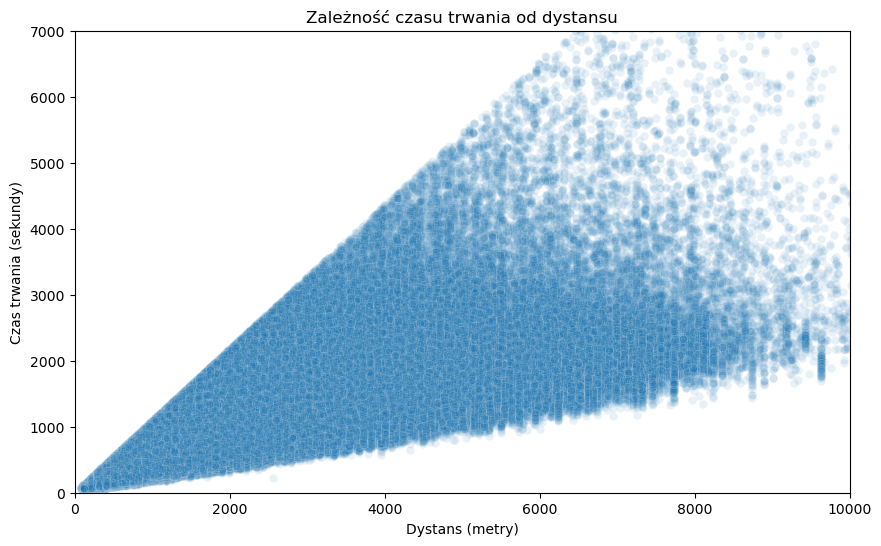

In [197]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_rentals['distance_m'], y=df_rentals['tripduration'], alpha=0.1)

# Opcjonalnie: ograniczenie widoku, jeśli masz ogromne outliery
plt.xlim(0, 10000) # np. do 10 km
plt.ylim(0, 7000)  # np. do 2 godzin

plt.title("Zależność czasu trwania od dystansu")
plt.xlabel("Dystans (metry)")
plt.ylabel("Czas trwania (sekundy)")
plt.show()

Analiza:
Uzyskany wynik pokazuje, że wraz ze zwrostem dystansu rośnie czas co jest zgodne z prawami fizyki. Zagęszczenie liczby wypożyczeń maleje wraz ze wzrostem dystansu. Dla większych dystansów czas staje się coraz bardziej rozrzcony. Dzieje się tak dlatego, że prędkość odgrywa coraz większe znaczenie. Wpływ może mieć także pogoda, gdyż w niekorzystnych warunkach pogodowych jedzie się wolniej a także czas wyporzyczenia. W godzinach szczytu rowerzyści częściej trafiali na czerwone światła i utrudnienia związane z większą liczbą samochodów. Algorytm może działać gorzej dla dłuższych tras przebutych przez rowerzystów.

Utworzenie macirzy korelacji między danymi

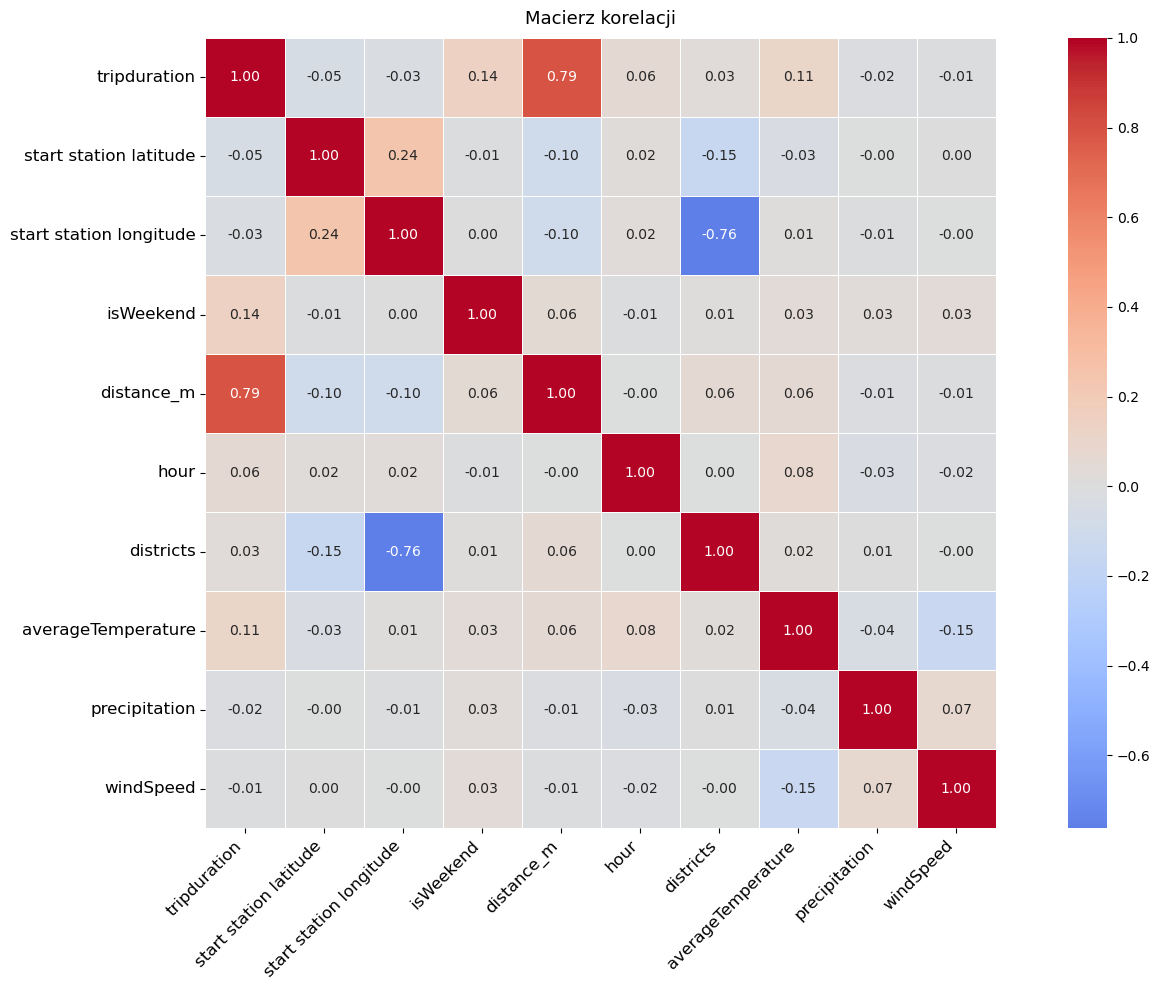

In [204]:
num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()

plt.figure(figsize=(15,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,       # pokazuje wartości korelacji
    fmt=".2f",        # 2 miejsca po przecinku
    linewidths=0.5,   # cienkie linie między kafelkami
    square=True,      # kwadratowe kafelki
    annot_kws={"size": 10}
)
plt.title("Macierz korelacji", fontsize=13, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

W analizie skupię się na zależnościach względem czasu trwania przejazdu czyli wektora celu. Największą korelację ma ona z dystansem co jest logiczne i zgodne z przewidywaniami. Wysoki wpływ ma także sprawdzenie czy wypożyczenie ma miejsce w weekend. Częściej w dni wolne z rowerów miejskich korzystają turyści czy osoby rekreacyjnie korzystające z roweru. Cecha określająca weekend jest skorelowana z długością trasy. Duży wpływ ma też temperatura, która zachęca do korzytsania z roweru i potencjalnie dłuższych lub powolniejszych przejazdów. Temperarura ma również wpływ na zmęczenie a więc na prędkość i pośśrednio na czas przejazdu. Średnią korelację odczytano z godziną wyporzyczenia. Inaczej jeździ się po mieście w godzinach szczytu i dużego ruchu a inaczej wieczorem czy nawet w nocy. Godzina determinuje również powód wypożyczenia roweru. Co ciekawe wiatr ma niewielki wpływ na długość wypożczcenia mimo, że ta cecha utrudnia jazdę na rowerze. Najprawdopodobiej na etapie samego wypożyczenia rowerzyści nie zwracali uwagi na wiatr. Jest on mniej odczuwalny podczas poruszania się na piechotę, a cel dojazdu staje się ważniejszy niż jego warunki. Dane pogodowe korelują z weekendem. Może to wynikać z powodu wypożyczenia i faktu, że częściej w weekend przejazdy są rekreacyjne i rower wybierany jest jako urozmaicenie środka transportu.

## Przygotowanie modelu

Wczytanie danych na których będzie uczyć się model. Na etapie wstępnego przygotowania danych wybrano tabelę z ograniczoną liczbą rekordów.

In [37]:
df = pd.read_csv('data/data_table_CLEAN.csv')   

Utworzenie wektora celu

In [38]:
target_col = "tripduration"
X = df.drop(columns=[target_col])
y = df[target_col]
num_cols = X.select_dtypes(include= [np.number]).columns.to_list()


Podział na dane treningowe i testowe w stosunku 8/2

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (813279, 10) (813279,)
Test : (203320, 10) (203320,)


Podział na kolumny numeryczne i kategoryczne. Jako, że dzielnice w Bostonie oznaczane są numerami zostały one zakwalifikowane jako dane kategoryczne a nie numeryczne.

In [40]:
num_cols = X.select_dtypes(include="number").columns
num_cols =  num_cols.drop("districts")
cat_columns = ["season", 'districts']

Skalowanie danych niezbędne dla algorytmu k-NearestNeighbour SPRAWDŹ

In [41]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_columns)
    ]
)

In [42]:
X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.fit_transform(X_test)

Wybór modeli
- Random Forest
- k-NN
- Hist Gradient Boosting

Początkowo zamiast Lasu Losowego zdecydowano się na algorytm SVM. Ze względu na długi czas wkonywania się algorytmu i fakt, że Gradient Boosting, działający na bazie drzew sprawdzał się najlepiej zamieniono SVM na Random Forest.
Zasmiast zwykłego Gradient Boosting wybrano Hist Gradient Boosting, ponieważ sprawdza się lepiej dla dużej liczby danych i przyspiesza obliczenia.

In [19]:
models = {
    "Random_Forest": RandomForestRegressor(),
    "k-NN": KNeighborsRegressor(),
    'HistGradientBoostingRegressor': HistGradientBoostingRegressor()
}

Przygotowanie siatki parametrów umożliwiającej dobranie najbardziej optymalnego algorytmu. Parametry dobrano na bazie dokumentacji.

In [24]:
param_grid = { 
    "Random_Forest":{
        "n_estimators": [300, 400, 500],
        'max_depth': [15, 20],
        "min_samples_split": [2],
        "min_samples_leaf": [2],
        "max_features": ["sqrt"]
    },

    "k-NN":{
        "n_neighbors": [18],
        "weights": ["uniform"],
    },   
        "HistGradientBoostingRegressor":{
        "max_iter": [1000, 1500],
        "learning_rate": [0.02],
        "max_leaf_nodes": [100, 150],
        "min_samples_leaf": [20, 30],
        "early_stopping": [True],

    }
    }

In [25]:
results = []
for name, model in models.items():
    if name in param_grid:
        print("Model", name)
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid[name],
            scoring="neg_root_mean_squared_error",  # minimalizujemy RMSE
            cv=5,
            n_jobs=-1,
            verbose=1,
            error_score="raise"
        )
        grid.fit(X_train_t, y_train)
        best_model = grid.best_estimator_
        elapsed = grid.refit_time_
        print("Najlepsze parametry:", grid.best_params_)
        print("Najlepszy wynik :", grid.best_score_)
    else:
        best_model = model
        start = time.perf_counter()
        best_model.fit(X_train_t, y_train)
        end = time.perf_counter()
        elapsed = end - start


    
    y_pred_tr = best_model.predict(X_train_t)
    y_pred_te = best_model.predict(X_test_t)

    mae_tr = mean_absolute_error(y_train, y_pred_tr)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    r2_tr = r2_score(y_train, y_pred_tr) 
    


    mae_te = mean_absolute_error(y_test, y_pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_te))
    r2_te = r2_score(y_test, y_pred_te)

    filename = name + ".joblib"
    dir = Path("models")
    joblib.dump(best_model, dir / filename)

    results.append({"Model": name, "mae_tr": mae_tr, "rmse_tr": rmse_tr, "r2_tr": r2_tr, "mae_te": mae_te, "rmse_te": rmse_te, "r2_te": r2_te, "time": f"{elapsed/60:.2f}"})


Model Random_Forest
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Najlepsze parametry: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Najlepszy wynik : -347.3616990338559
Model k-NN
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Najlepsze parametry: {'n_neighbors': 18, 'weights': 'uniform'}
Najlepszy wynik : -386.37300041655567
Model HistGradientBoostingRegressor
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\kubaz\miniconda3\envs\alum\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Najlepsze parametry: {'early_stopping': True, 'learning_rate': 0.02, 'max_iter': 1500, 'max_leaf_nodes': 150, 'min_samples_leaf': 20}
Najlepszy wynik : -362.1272359669224


Random_Forest /n
Najlepsze parametry: 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400
Najlepszy wynik : -347.35895400565704
Model k-NN
Najlepsze parametry: 'n_neighbors': 18, 'weights': 'uniform'
Najlepszy wynik : -386.37300041655567
Model HistGradientBoostingRegressor
Najlepsze parametry: 'early_stopping': True, 'l2_regularization': 20, 'learning_rate': 0.02, 'max_iter': 1500, 'max_leaf_nodes': 100, 'min_samples_leaf': 30
Najlepszy wynik : -366.2888766602565

In [26]:
results_df = pd.DataFrame(results)
display(results_df)

,Model,mae_tr,rmse_tr,r2_tr,mae_te,rmse_te,r2_te,time
0,Random_Forest,177.304261,276.120083,0.823147,217.916053,345.262279,0.723675,2.31
1,k-NN,231.670531,362.944572,0.694439,245.254545,384.580746,0.657155,0.00
2,HistGradientBoostingRegressor,219.436499,339.416524,0.732771,230.281777,364.094140,0.692709,1.16


#### Analiza
Uzyskane wyniki dla wszytskich modeli są akceptowalne dla przpadku wypożycznień rowerów. Błąd na poziomie kilku minut nie będzie znacząco odrzucający dla potencjalnego użytkownika. Algorytmy popełniały również znaczące błędy co widać po wyższej wartości Root Mean Squared Error. Jednak różnice między MAE i RMSE są akceptowalne. Z problemem lepiej poradziły sobie algorytmy bazujące na drzewach. Odnalazły lepiej wartości odstające i mniej typowe. Wynika to z charakterystyki danych i faktu, że wiele zależy od rowerzysty i jego prędkości.
Modele przedstawiono w kolejności od najlepszego do najgorszego
1. Random Forest:
Uzyskał najlepszzy wynik dla MAE jest najniższy i wynosi 177.30 sekundy czyli 2.9 minut. Błąd RSME jest nieznacznie większy, jednak różnicę można uznać za akceptowalną. Model jest lekko niedouczony, gdyż dla danych testowych uzyskał gorsze rezultaty Model ma najwyższy wynik $R^2$. Został uznany za najlepszy model ze względu na najlepsze wyniki wszystkich parametrów. Wadą tego algorytmu jest fakt, że jego czas wykonania jest najdłuższy.
2. Hist Gradient Boosting
Uzyskał znacznie gorsze wyniki MAE oraz RMSE. Jest najszybszym algorytmem, co stanowi jego przewagę. SPodziewano się, że ten model uzyska lepsze rezultaty niż Random Forest. Model gorzej dopasowywuje się do danych.
3. k- Nearest Neighbor
Uzyskał najgorszy wynik spośród wybranych algorytmów. Może świadczyć to o tym, że w typ przypadku bazowanie na sąsiadach daje gorsze rezultaty. Algorytm wykrywa bardziej typowe przypadki, ma natomiast problem z odchyleniami.
##### Podsumowanie
Do dalszej analizy wybrano model Random Forest jako najlepszy z badanych. Wyniki $r^2$ dla danych testowych za pewne poprawiłyby się gdyby zmienić stosunek podziału danych np. na 70/30

In [27]:
model = joblib.load("models/Random_Forest.joblib")


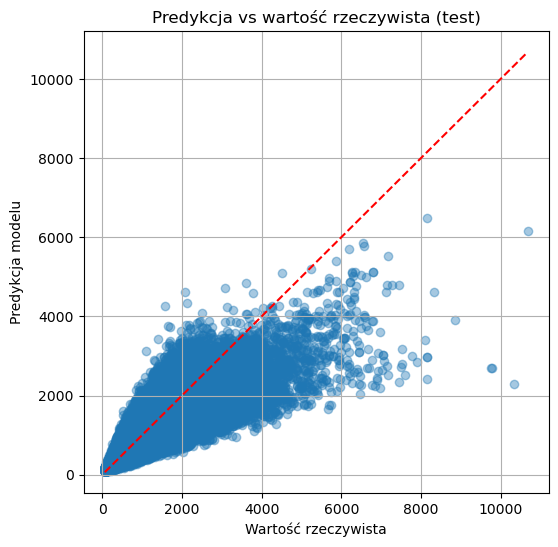

In [28]:
y_pred = model.predict(X_test_t)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
            linestyle="--", color = "r"),
plt.xlabel("Wartość rzeczywista")
plt.ylabel("Predykcja modelu")
plt.title("Predykcja vs wartość rzeczywista (test)")
plt.grid(True)
plt.show()

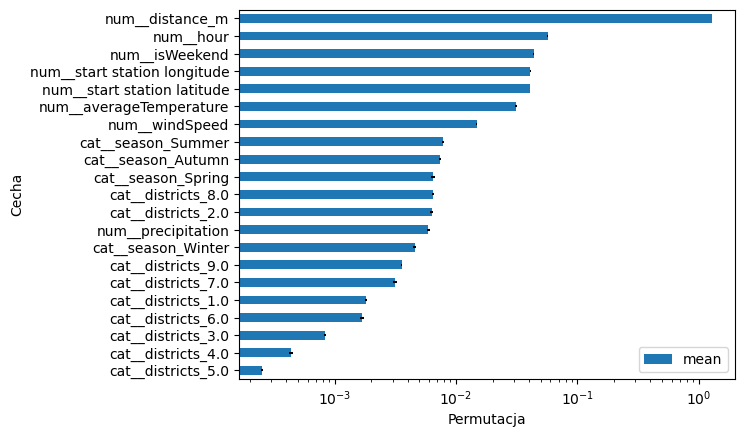

In [30]:
feature_names = preprocess.get_feature_names_out()

result = permutation_importance(model, X_test_t, y_test, n_repeats=10, random_state=42)

features_df = pd.DataFrame({
    'mean': result.importances_mean,
    "std": result.importances_std,
    "names": feature_names,
    },)

features_df = features_df.sort_values(by = "mean", ascending=True)
features_df.plot.barh(x = 'names', y = "mean", xerr = "std", stacked = True)
plt.ylabel("Cecha")
plt.xlabel("Permutacja")
plt.xscale("log")
plt.show()



Największy wpływ na wynik miała cecha distance co powiązane jest z największą korelacją. Co ciekawe cecha reprezenutjąca godzinę wypożyczenia umiejscowiła się na drugim miejscu mimo średniej korelacji z cechą celu. Reszta cech poza dzielnicami nie odbiega znacząco od siebie. Warto zauważyć że dzielnice 2 i 8 miały wyjątkowo wysoki wpływ na wynik. Zastosowano skalę logarytmiczną aby lepiej zobaczyć różnicę między wynikami dla poszczególnych cech ze względu na dominację dystansu

## Sztuczne sieci neuronowe
Uczenie sztucznych sieci neuronowych ptzygotowano przy użyciu pipeline. Zastosowano early stopping aby uniknąć przeuczenia. Ustawiono parametr max_iter na 1000 aby algorytm mógł zrozumieć dane przy zachowaniu zdrowego czasu obliczeń. Taa wartość nie została w pełni wykorzystana.

In [10]:
mlp_pipe = Pipeline([
    ("prep", preprocess),
    ("model", MLPRegressor(
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=40,
        max_iter=1000,
        random_state=42
    ))
])

Przygotowany grid bada sieci jedno i dwó warstwowe dla kombinacji 32 i 64 neuronów.

In [11]:
param_grid = {
    "model__hidden_layer_sizes": [(32,), (64,), (32, 32), (64, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-4, 1e-3],              
    "model__learning_rate_init": [0.001, 0.01],
}


In [12]:
grid = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=2
)

start = time.perf_counter()
grid.fit(X_train, y_train)
end = time.perf_counter()
elapsed = end - start


print("\nNajlepsze parametry:", grid.best_params_)
print("Najlepszy wynik CV (neg RMSE):", grid.best_score_)
print(f"Czas: ({elapsed/60:.2f} min)")

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Najlepsze parametry: {'model__activation': 'relu', 'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 64), 'model__learning_rate_init': 0.001}
Najlepszy wynik CV (neg RMSE): -378.03104371191745
Czas: (183.74 min)


In [13]:
best_mlp = grid.best_estimator_

# Early stopping info:
mlp_step = best_mlp.named_steps["model"]
print(f"Early stopping po {mlp_step.n_iter_} iteracjach")

best_model = grid.best_estimator_

y_pred_train = best_mlp.predict(X_train)
y_pred_test  = best_mlp.predict(X_test)

rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_tr = mean_absolute_error(y_train, y_pred_train)
mae_te = mean_absolute_error(y_test, y_pred_test)
r2_tr = r2_score(y_train, y_pred_train)
r2_te = r2_score(y_test, y_pred_test)

print("=== Srawdzenie modelu ===")
print(f"TRAIN: MAE={mae_tr:.3f} | RMSE={rmse_tr:.3f} | R2={r2_tr:.3f}")
print(f"TEST : MAE={mae_te:.3f} | RMSE={rmse_te:.3f} | R2={r2_te:.3f}")

Early stopping po 184 iteracjach
=== Srawdzenie modelu ===
TRAIN: MAE=238.126 | RMSE=376.642 | R2=0.671
TEST : MAE=239.283 | RMSE=379.194 | R2=0.667


### Analiza
Najlepszą siecią okazała się sieć dwuwarstowa z 64 neuronami w każdej warstwie. Do treningu wystarczyło 1000 iteracji. Wy wynikach widoczny jest minimalny overfitting natomiast wyniki dla zbioru testowego i trenignowego są niemal identyczne. Sieć gorzej dopasowała się do danych niż modele uczenia maszynowego i uzyskała gorsze wyniki. Nadal dla wypożyczenia roweru błąd na poziomie 4 minut jest akceptowalny. Zdecydowano się nie rozwijać parametrów sieci neuronowej ze względu na zdecydowanie gorsze wyniki i ograniczoną moc obliczeniową komputera

In [ ]:
joblib.dump(best_mlp, "models/best_MLP_FCH_pipeline.joblib")

['modelsbest_MLP_FCH_pipeline.joblib']

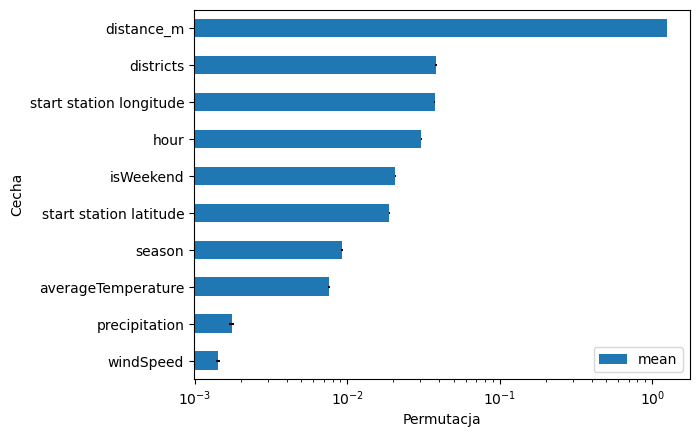

In [15]:
feature_names_lm = X_train.columns

result_lm = permutation_importance(best_mlp, X_train, y_train, n_repeats=10, random_state=42)

features_df = pd.DataFrame({
    'mean': result_lm.importances_mean,
    "std": result_lm.importances_std,
    "names": feature_names_lm,
    },)

features_df = features_df.sort_values(by = "mean", ascending=True)
features_df.plot.barh(x = 'names', y = "mean", xerr = "std")
plt.ylabel("Cecha")
plt.xlabel("Permutacja")
plt.xscale("log")
plt.show()

#df.head(23)


Największy wpływ na wynik ma czas dystans podobnie jak w przypadku uczenia maszynowego. Najniższy wpływ mają windspeed i precipitation, które znacznie zostają w tyle za pozostałymi cechami. W stosunku do modeli uczenia maszynowego znacznie większe znaczenie ma położenie stacji.

# Podsumowaie i wnioski
W ramach projektu przygotowano dane o wypożyczeniach rowerów miejskich i pogodzie w Bostonie. Na ich podstawie wytrenowano trzy modele uczenia maszynowego i wybrano model Random Forest. Dla danego problemu i zestawu danych lepiej sprawdziły się modele uczenia maszynowego niż sieć nuronowa. Przeciętne wyniki dopasowania do danych możnaby poprawić bardziej restrykcyjnie przycinając czas wypożyczenia. Obawiano się jednak o nadmierne spłaszczenie danych co mogłoby spododować spadek jakości algorytmu na dłuższych trasach. Zauważono też znaczenie rozmiaru zestawu danych. Dla przyciętej liczby rekordów lepiej sprawdzały się płytsze drzewa i mniejsza ich ilość a także mniejsza liczba sąsiadów. Zmiana na pełny zestaw danych wymagała znacznej zmiany parametrów. Co ciekawe dla sieci neuronowej różnica między przyciętą a pełną bazą danych nie była znacząca jeśli chodzi o parametry oceny. Z baadania można wysnuć wniosek, że sieć neuronowa nie zawsze jest lepszym rozwiązaniem, a czas obliczeń jest większy niż w przypadku modeli. Zdecydowanym przyspieszeniem obliczeń okazało się zastosowanie intelx, zmiana formatu danych z float64 na float32 oraz zastosowanie Hist Gradient Boosting zamiast Gradient Boosting. Wyniki projektu pokazały, że wyciąganie dodatkowych cech na podstawie surowych danych poprawia wyniki algorytmów. Proces przygotowania danych pozwolił przećwiczyć metody znajdowania błędów w danych oraz wartości odstających. Nauczono się tworzyć nowe kolumny oraz wykonywać złączenia przestrzenne w języku Python. Uczenie sieci neuronowych i modeli pozwoliło zgłębić wiedzę na temat doboru parametrów oraz analizy uzyskanych wyników. Zapoznano się z problemem doboru celu i faktu, że nie w każdym przypadku uczenie maszynowe daje idealne rezultaty i nie jest w stanie rozwiązać wszystkich problemów.